## Model Explainability

### Setup

In [1]:
# Standard Libraries
import os
import math
import json
import datetime
from pathlib import Path
import multiprocessing

# Data Handling
import numpy as np
import pandas as pd
import nibabel as nib

# Visualization
import matplotlib.pyplot as plt
from tqdm import tqdm

# Image & Augmentation
import cv2
import albumentations as alb

# Machine Learning & PyTorch
import torch
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast
from torchvision.transforms import transforms
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split

# MONAI - Medical Imaging
from monai.networks.nets import UNETR, UNet
from monai.networks.nets import AttentionUnet as MAttentionUnet
from monai.networks.utils import one_hot
from monai.transforms import AsDiscrete
from monai.data import decollate_batch
from monai.losses import DiceLoss, DiceCELoss, HausdorffDTLoss
from monai.metrics import DiceMetric
from monai.visualize import GradCAM

# Privacy & Logging
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
import wandb

/home/hakeem.at/.conda/envs/BTSeg/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.5' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
seed = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


### Data

In [3]:
def create_dataset_path_df(dataset_dir):
    flair_suffix = "flair.nii.gz"
    t1_suffix = "t1.nii.gz"
    t1ce_suffix = "t1ce.nii.gz"
    t2_suffix = "t2.nii.gz"
    seg_suffix = "seg.nii.gz"
    dataset_dict = {
                    'directory_path':[],
                    'flair_path':[],
                    't1_path':[],
                    't1ce_path':[],
                    't2_path':[],
                    'seg_path':[]
                    }
    missing_flair = 0
    missing_t1 = 0
    missing_t1ce = 0
    missing_t2 = 0
    missing_seg = 0
    missing_files_dirs = []
    for dir in os.listdir(dataset_dir):
        dir_path = os.path.join(dataset_dir,dir)
        if not os.path.isdir(dir_path) or not dir.startswith('BraTS2021'):
            continue
        dataset_dict['directory_path'].append(dir_path)
        
        flair_found = t1_found = t1ce_found = t2_found = seg_found = False
        for image in os.listdir(dir_path):
            image_path = os.path.join(dir_path, image)

            if image.endswith(flair_suffix):
                dataset_dict['flair_path'].append(image_path)
                flair_found = True
            elif image.endswith(t1_suffix):
                dataset_dict['t1_path'].append(image_path)
                t1_found = True
            elif image.endswith(t1ce_suffix):
                dataset_dict['t1ce_path'].append(image_path)
                t1ce_found = True
            elif image.endswith(t2_suffix):
                dataset_dict['t2_path'].append(image_path)
                t2_found = True
            elif image.endswith(seg_suffix):
                dataset_dict['seg_path'].append(image_path)
                seg_found = True

        if not flair_found:
            dataset_dict['flair_path'].append(None)
            missing_flair += 1
        if not t1_found:
            dataset_dict['t1_path'].append(None)
            missing_t1 += 1
        if not t1ce_found:
            dataset_dict['t1ce_path'].append(None)
            missing_t1ce += 1
        if not t2_found:
            dataset_dict['t2_path'].append(None)
            missing_t2 += 1
        if not seg_found:
            dataset_dict['seg_path'].append(None)
            missing_seg += 1
        if flair_found or t1_found or t1ce_found or t2_found or seg_found:
            pass
        else:
            missing_files_dirs.append(dir_path)
    print(f"Total missing files:")
    print(f"  - Flair: {missing_flair}")
    print(f"  - T1: {missing_t1}")
    print(f"  - T1ce: {missing_t1ce}")
    print(f"  - T2: {missing_t2}")
    print(f"  - Seg: {missing_seg}")
    print(f"Missing files at: {missing_files_dirs}")
    return pd.DataFrame(dataset_dict)

    return dataset_dict
dataset_dir = "../data/brats2021"
dataset = create_dataset_path_df(dataset_dir)
dataset.head()

Total missing files:
  - Flair: 0
  - T1: 0
  - T1ce: 0
  - T2: 0
  - Seg: 0
Missing files at: []


,directory_path,flair_path,t1_path,t1ce_path,t2_path,seg_path
0,../data/brats2021/BraTS2021_00000,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...
1,../data/brats2021/BraTS2021_00002,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...
2,../data/brats2021/BraTS2021_00003,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...
3,../data/brats2021/BraTS2021_00005,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...
4,../data/brats2021/BraTS2021_00006,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...


In [4]:
train_size = 0.8
val_size = 0.1
test_size = 0.1
random_state = 42
dataset_train, temp = train_test_split(dataset, test_size = val_size+test_size, random_state = random_state)
dataset_val, dataset_test = train_test_split(temp, test_size = test_size / (val_size + test_size), random_state = random_state)
print(f"Train set shape: {dataset_train.shape}")
print(f"Validation set shape: {dataset_val.shape}")
print(f"Test set shape: {dataset_test.shape}")

Train set shape: (1000, 6)
Validation set shape: (125, 6)
Test set shape: (126, 6)


### Custom Dataset Class

In [5]:
class BrainTumorDataset(Dataset):
    def __init__(self, datapath_df, upper_bound=100, lower_bound=60, window_size = 3, new_height=None, new_width=None,transformations=None):
        self._datapath_df = datapath_df
        self.upper_bound = upper_bound
        self.lower_bound = lower_bound
        self.window_size = window_size
        self.transformations = transformations

    def __len__(self):
        return self._datapath_df.shape[0]

    def _normalize_data(self, volume):
        mean = np.mean(volume)
        if mean==0:
            mean = 1
        std = np.std(volume)
        return (volume-mean)/std

    def _get_adjacent_slices(self, data, mask):
        slices = []
        masks = []
        
        depth = data.shape[-1]
        start = max(self.lower_bound, 0)
        end = min(self.upper_bound, depth)
        
        for i in range(start, end - self.window_size + 1):
            if self.window_size == 1:
                slice_group = data[:, :, :, i].transpose(1, 2, 0).astype(np.float32)
            else:
                slice_group = np.concatenate(
                    [data[:, :, :, j].transpose(1, 2, 0).astype(np.float32) for j in range(i, i + self.window_size)], 
                    axis=-1
                )
            slices.append(slice_group)
            masks.append(mask[:, :, i + self.window_size // 2].astype(np.uint8))
        
        return slices, masks

    def __getitem__(self, index):
        data = []
        row = self._datapath_df.iloc[index]
        data.append(self._normalize_data(nib.load(row.flair_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t1_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t1ce_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t2_path).get_fdata()))
        data = np.stack(data, axis=0)
        height = data.shape[1] if not new_height else new_height
        width = data.shape[2] if not new_width else new_width
        num_modalities = data.shape[0]
        num_slices = self.window_size


        mask = nib.load(row.seg_path).get_fdata()
        mask[mask == 4] = 3
        data, mask = self._get_adjacent_slices(data, mask)
        if self.transformations:
            spatial_transforms = self.transformations.get('spatial_transforms',None)
            intensity_transforms = self.transformations.get('intensity_transforms',None)

            if spatial_transforms:
                for i in range(len(data)):
                    augmented_data = spatial_transforms(image=data[i], mask=mask[i])
                    data[i], mask[i] = augmented_data["image"], augmented_data["mask"]
            if intensity_transforms:
                for i in range(len(data)):
                    augmented_data = intensity_transforms(image=data[i])
                    data[i] = augmented_data["image"]

        for i in range(len(data)):
            data[i] = data[i].reshape((height, width, num_slices, num_modalities))
            data[i] = data[i].transpose(3, 2, 0, 1)
        return data, mask

In [6]:
new_height = 240
new_width = 240
percentage_crop = 30
transformations = {}
val_transformations = {}
val_spatial_transforms = alb.Compose([
    alb.PadIfNeeded(min_height=new_height, min_width=new_width),
    alb.Resize(new_height, new_width)
], additional_targets={"mask":"mask"})

In [7]:
upper_bound=100
lower_bound=60
window_size = 1
num_modalities = 4
val_data = BrainTumorDataset(dataset_val,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             new_height = new_height,
                             new_width = new_width,
                             transformations=val_transformations)
pd.Series({
    'Validation dataset size:': len(val_data),
}).to_frame().style.hide(axis='columns')

Validation dataset size:,125


In [8]:
def collate_fn(batch):
    data = []
    mask = []
    for X, label in batch:
        data.extend(X)
        mask.extend(label)
    data = np.array(data)
    mask = np.array(mask)
    data = torch.tensor(data, dtype=torch.float32)
    mask = torch.tensor(mask, dtype=torch.float32)
    return data, mask

per_datapoint_batch_size = (upper_bound-lower_bound)-window_size+1
batch_size_multiplication_factor = 2
batch_size = int(per_datapoint_batch_size*batch_size_multiplication_factor)
num_workers = 3
persistent_workers = True
pin_memory = True if device=='cuda' else False
pin_memory_device = device
data_loader_params = {
    'batch_size': batch_size_multiplication_factor,
    'num_workers': num_workers,
    'persistent_workers': persistent_workers,
    'pin_memory': pin_memory,
    'pin_memory_device': pin_memory_device,
    'collate_fn': collate_fn,
}
print(f'Number of datapoints per batch {batch_size}')
val_dataloader = DataLoader(val_data, **data_loader_params)

Number of datapoints per batch 80


/home/hakeem.at/.conda/envs/BTSeg/lib/python3.12/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [9]:
pd.Series({
    'Number of batches in validation dataLoader:': len(val_dataloader),
}).to_frame().style.hide(axis='columns')

Number of batches in validation dataLoader:,63


In [10]:
for batch_idx, (data, mask) in enumerate(val_dataloader):
    print("Unique values in masks:", torch.unique(mask))
    
    print(f"Batch {batch_idx}:")
    print(f"  Data shape: {data.shape}")
    print(f"  Mask shape: {mask.shape}")
    break

Unique values in masks: tensor([0., 1., 2., 3.])
Batch 0:
  Data shape: torch.Size([80, 4, 1, 240, 240])
  Mask shape: torch.Size([80, 240, 240])


### Model

In [11]:
class UNET_V0(torch.nn.Module):
    def __init__(self,):
        super(UNET_V0, self).__init__()
        self.unet = MAttentionUnet(
                        spatial_dims=2,       # Specifies a 2D UNet (for slice-wise medical image segmentation)
                        in_channels=int(num_modalities*window_size),       # Number of input channels (e.g., multi-modal MRI with 12 input features)
                        out_channels=4,       # Number of output channels (multi-class segmentation with 4 classes)
                        channels=(16, 32, 64, 128),  # Number of feature maps at each level of the UNet
                        strides=(2, 2, 1, 1),  # Down-sampling factor at each level of the encoder (reduces spatial size)
                        kernel_size=3,        # Convolution kernel size
                        up_kernel_size=3,     # Kernel size for upsampling layers
                        dropout=0.3,          # Dropout rate for regularization (optional)
                    )

    def forward(self, X):
        X = self.unet(X)
        return X

In [12]:
model_path = '../checkpoints/BrainTumorSegmentation_V1/2025-03-27_11-46-28/UNET_V0.pth'
checkpoint = torch.load(model_path, map_location = device)
model = UNET_V0().to(device)
model.load_state_dict(checkpoint)
num_params = sum(p.numel() for p in model.parameters())
print('Number of parameters: {:.3f}K'.format(num_params / 1000))

Number of parameters: 494.456K


(-0.5, 239.5, 239.5, -0.5)

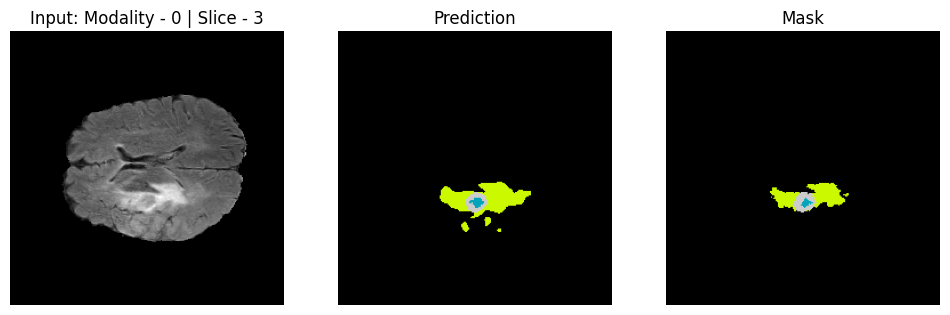

In [13]:
data, masks = next(iter(val_dataloader))
idx = np.random.randint(data.shape[0])
data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
data = data[idx,...].unsqueeze(0)
masks = masks[idx,...]
model.eval()
with torch.no_grad():
    logits = model(data.to(device))

probs = torch.softmax(logits, dim=1)
preds = torch.argmax(logits, dim=1)


modality = 0 # 0-2, 3-5, 6-8, 9-11
slice_num = 3
scan = data.squeeze(0)[modality].cpu().numpy()
pred = preds.squeeze(0).cpu().numpy()
mask = masks.cpu().numpy()

plt.figure(figsize=(12,12))
plt.subplot(1,3,1)
plt.imshow(scan, cmap="grey")
plt.title(f"Input: Modality - {modality} | Slice - {slice_num}")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(pred, cmap="nipy_spectral")
plt.title("Prediction")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(mask, cmap="nipy_spectral")
plt.title("Mask")
plt.axis('off')

### Explainability

In [14]:
for name, _ in model.named_modules(): print(name)


unet
unet.model
unet.model.0
unet.model.0.conv
unet.model.0.conv.0
unet.model.0.conv.0.conv
unet.model.0.conv.0.adn
unet.model.0.conv.0.adn.N
unet.model.0.conv.0.adn.D
unet.model.0.conv.0.adn.A
unet.model.0.conv.1
unet.model.0.conv.1.conv
unet.model.0.conv.1.adn
unet.model.0.conv.1.adn.N
unet.model.0.conv.1.adn.D
unet.model.0.conv.1.adn.A
unet.model.1
unet.model.1.attention
unet.model.1.attention.W_g
unet.model.1.attention.W_g.0
unet.model.1.attention.W_g.0.conv
unet.model.1.attention.W_g.1
unet.model.1.attention.W_x
unet.model.1.attention.W_x.0
unet.model.1.attention.W_x.0.conv
unet.model.1.attention.W_x.1
unet.model.1.attention.psi
unet.model.1.attention.psi.0
unet.model.1.attention.psi.0.conv
unet.model.1.attention.psi.1
unet.model.1.attention.psi.2
unet.model.1.attention.relu
unet.model.1.upconv
unet.model.1.upconv.up
unet.model.1.upconv.up.conv
unet.model.1.upconv.up.adn
unet.model.1.upconv.up.adn.N
unet.model.1.upconv.up.adn.D
unet.model.1.upconv.up.adn.A
unet.model.1.merge
unet

In [15]:
cam = GradCAM(model, target_layers="unet.model.1.submodule.1.submodule.1.submodule.conv.1.adn.A")

In [16]:
explainability_map = cam(x=data.to(device),class_idx=3).squeeze(0).squeeze(0).cpu().numpy()
explainability_map.shape

(240, 240)

In [17]:
heatmap = (explainability_map - explainability_map.min())/(explainability_map.max() - explainability_map.min() + 1e-8)

In [18]:
heatmap = cv2.applyColorMap(np.uint8(heatmap*255),cv2.COLORMAP_JET)

In [19]:
org_image = data.squeeze(0)[0].cpu().numpy()
org_image = (org_image - org_image.min())/(org_image.max() - org_image.min() + 1e-8)
org_image = np.uint8(org_image*255)
overlay = cv2.addWeighted(cv2.cvtColor(org_image,cv2.COLOR_GRAY2BGR),0.6, heatmap, 0.4, 0)

(-0.5, 239.5, 239.5, -0.5)

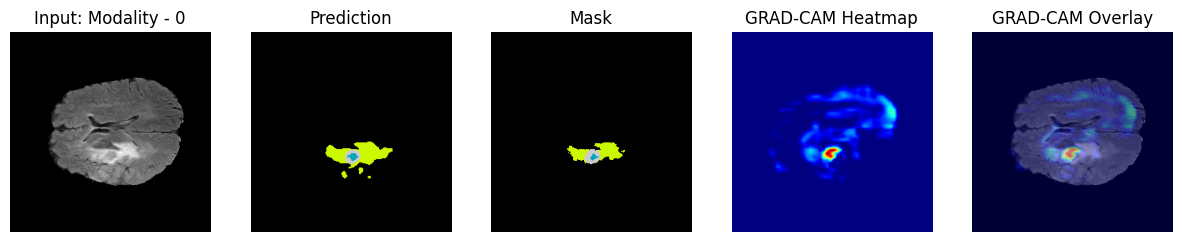

In [20]:
plt.figure(figsize=(15,15))
plt.subplot(1,5,1)
plt.imshow(scan, cmap="grey")
plt.title(f"Input: Modality - {modality}")
plt.axis('off')
plt.subplot(1,5,2)
plt.imshow(pred, cmap="nipy_spectral")
plt.title("Prediction")
plt.axis('off')
plt.subplot(1,5,3)
plt.imshow(mask, cmap="nipy_spectral")
plt.title("Mask")
plt.axis('off')
plt.subplot(1,5,4)
plt.imshow(heatmap, cmap="jet")
plt.title("GRAD-CAM Heatmap")
plt.axis('off')
plt.subplot(1,5,5)
plt.imshow(overlay)
plt.title("GRAD-CAM Overlay")
plt.axis('off')